In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"
import pandas as pd
import numpy as np
import random
import pickle
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
# from ucimlrepo import fetch_ucirepo 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split

from data.data_loader import PowerConsumptionDataset
from models.lstm import LSTMModel
from models.lstm_attention import LSTMWithAttention
from models.gru import GRUModel
from models.utils import create_model, train_and_evaluate, load_model
from explainers.lime import LimeExplainer
from explainers.shap import ShapExplainer
from explainers.attention import AttentionExplainer

In [2]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [63]:
# 'LSTM' or 'GRU' for LIME and SHAP, 'LSTM_Attention' for 'Attention' 
model_name = 'LSTM'  
hidden_size = 50
num_layers = 2
output_size = 1
dropout = 0.2
num_epochs = 50
batch_size = 64
learning_rate = 0.001
sequence_length = 60  # e.g., past 60 minutes
num_of_features = 4
feature_idx = [0, 1, 2, 3]
input_size = num_of_features  # Number of total features in the dataset

model_path = ('./trained_models/{}_features_' + '_'.join(['{}'] * len(feature_idx)) + '.pth').format(model_name, *feature_idx)
lime_path = './trained_explainer/lime_explainer_config.json'

In [64]:
dataset = PowerConsumptionDataset(file_path='data/household_power_consumption.txt',
                                  feature_idx = feature_idx,
                                  num_of_features=num_of_features)
train_sequences, eval_sequences, train_targets, eval_targets = dataset.load_data()

/archive/workspace/XAI/co-work/data/data_loader.py:24: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data = pd.read_csv(self.file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']},
/archive/workspace/XAI/co-work/data/data_loader.py:24: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv(self.file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']},
/archive/workspace/XAI/co-work/data/data_loader.py:24: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data = pd.read_csv(self.file_path, sep=';', parse_dates

In [66]:
model = create_model(model_name, input_size, hidden_size, num_layers, output_size, dropout)

# Check if the model already exists
if os.path.exists(model_path):
    print(f"Loading the pre-trained {model_name} model...")
    model = load_model(model, model_path)
    model.to(device)
else:
    print(f"Training a new {model_name} model...")
    train_and_evaluate(model, train_sequences, train_targets, 
                       eval_sequences, eval_targets, model_path,
                       num_epochs, batch_size, learning_rate)

Loading the pre-trained LSTM model...


## Explain

### LIME

In [19]:
explainer_type = 'LIME'  # or 'SHAP'

if explainer_type == 'LIME':
    explainer = LimeExplainer(model, device, train_sequences, 
                              sequence_length=60, input_size=input_size, 
                              selected_features=dataset.selected_features)
elif explainer_type == 'SHAP':
    explainer = ShapExplainer(model, device, train_sequences, 
                              sequence_length=60, input_size=input_size, 
                              selected_features=dataset.selected_features)
else:
    raise ValueError(f"Explainer type '{explainer_type}' is not recognized.")

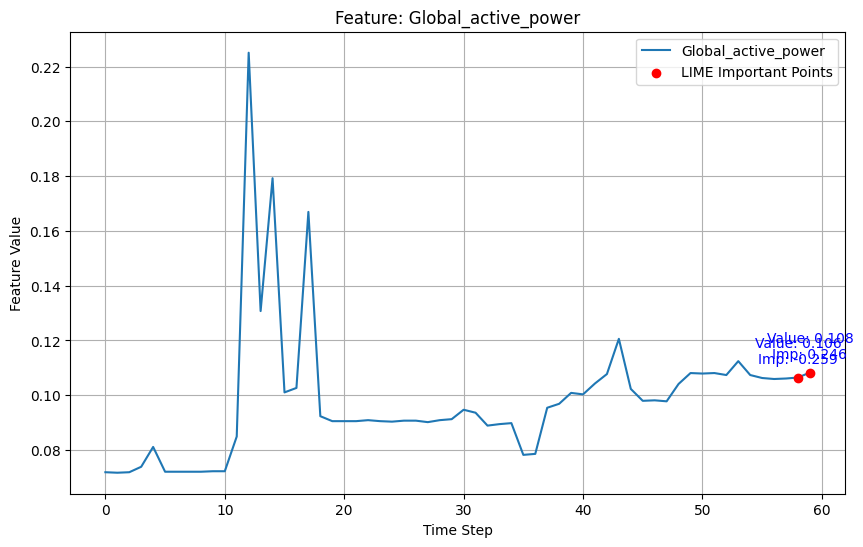


Feature: Global_active_power - Detailed Information
Time Step: 58, Feature Value: 0.106, Importance: -0.259
Time Step: 59, Feature Value: 0.108, Importance: 0.246


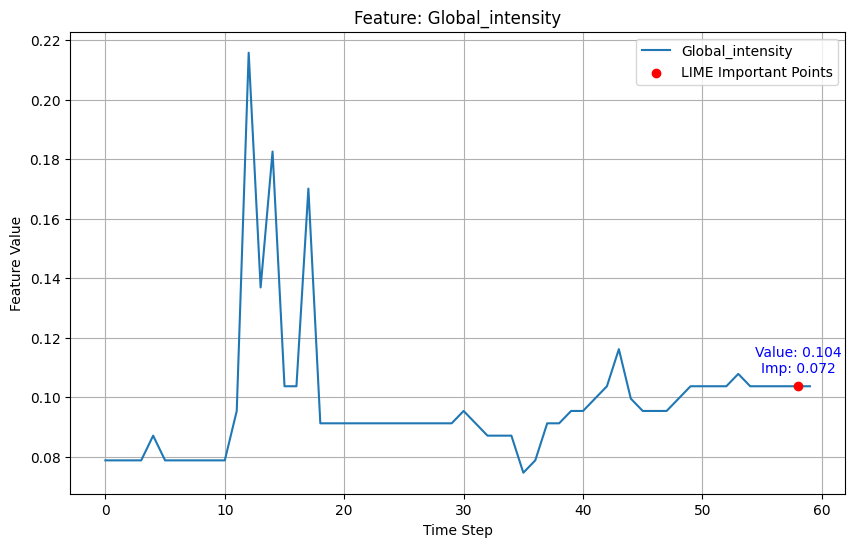


Feature: Global_intensity - Detailed Information
Time Step: 58, Feature Value: 0.104, Importance: 0.072


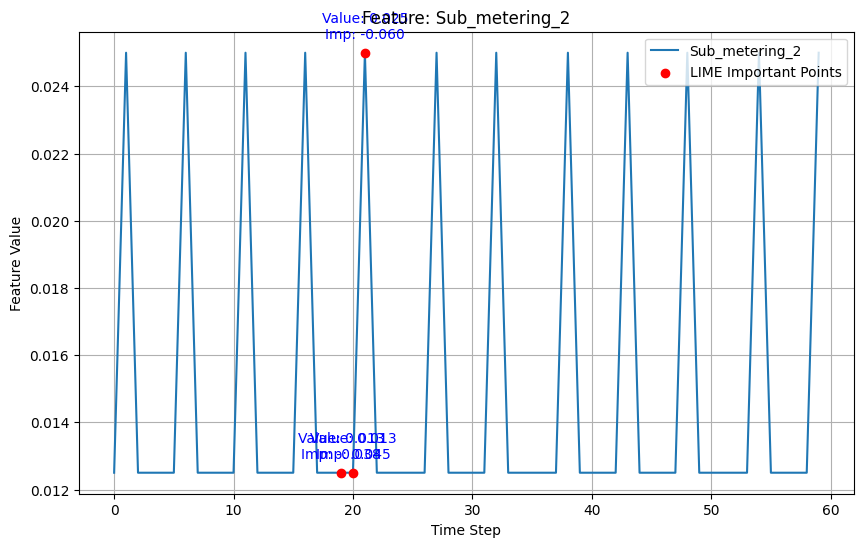


Feature: Sub_metering_2 - Detailed Information
Time Step: 21, Feature Value: 0.025, Importance: -0.060
Time Step: 20, Feature Value: 0.013, Importance: 0.045
Time Step: 19, Feature Value: 0.013, Importance: -0.038


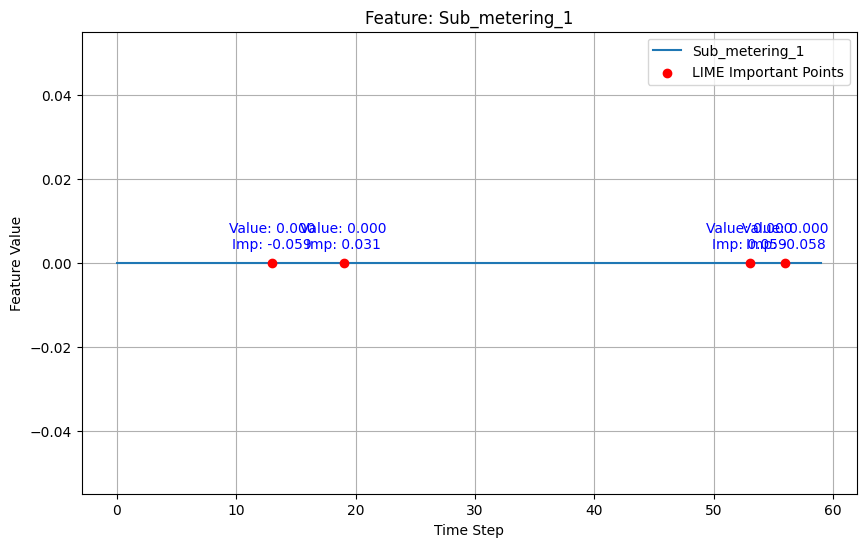


Feature: Sub_metering_1 - Detailed Information
Time Step: 13, Feature Value: 0.000, Importance: -0.059
Time Step: 53, Feature Value: 0.000, Importance: 0.059
Time Step: 56, Feature Value: 0.000, Importance: -0.058
Time Step: 19, Feature Value: 0.000, Importance: 0.031


In [20]:
# Explain a specific data point
explanation = explainer.explain(train_sequences[1])

### SHAP

In [9]:
explainer_type = 'SHAP' 

if explainer_type == 'LIME':
    explainer = LimeExplainer(model, device, train_sequences, 
                              sequence_length=60, input_size=input_size, 
                              selected_features=dataset.selected_features)
elif explainer_type == 'SHAP':
    explainer = ShapExplainer(model, train_sequences, sequence_length, 
                              input_size, dataset.selected_features, device)

else:
    raise ValueError(f"Explainer type '{explainer_type}' is not recognized.")

  0%|          | 0/1 [00:00<?, ?it/s]

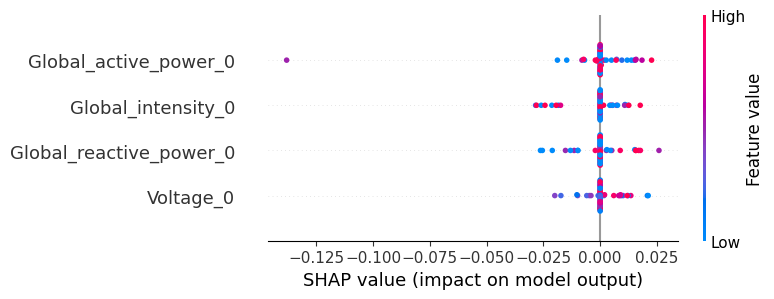

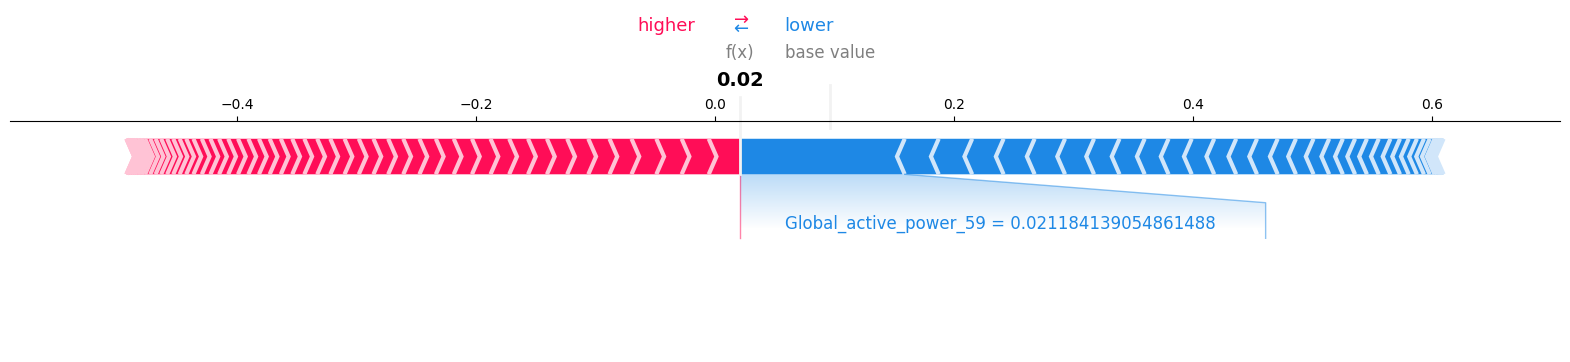

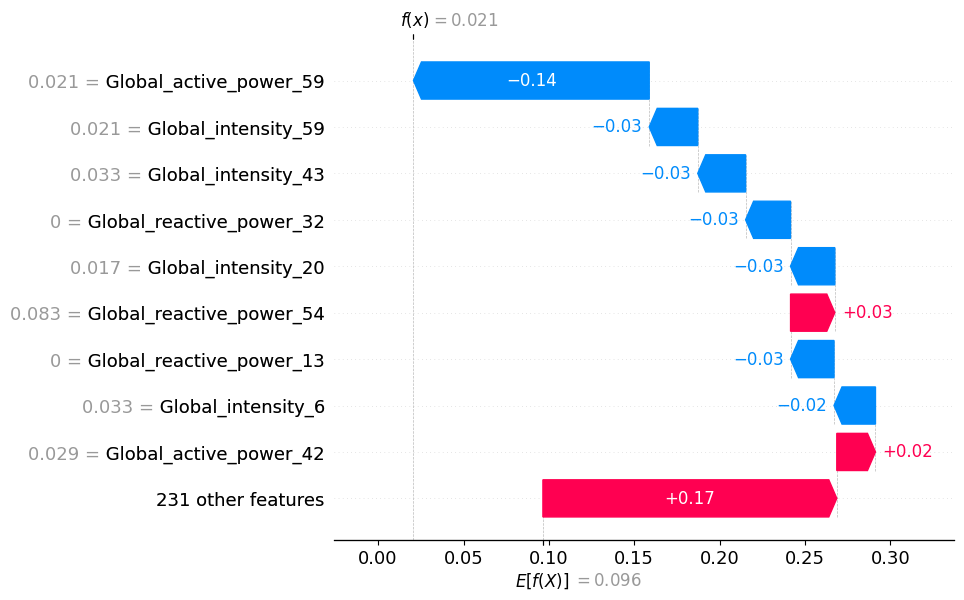

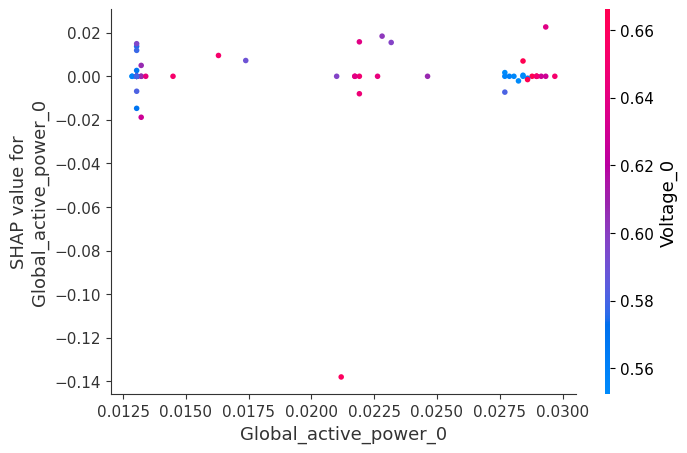

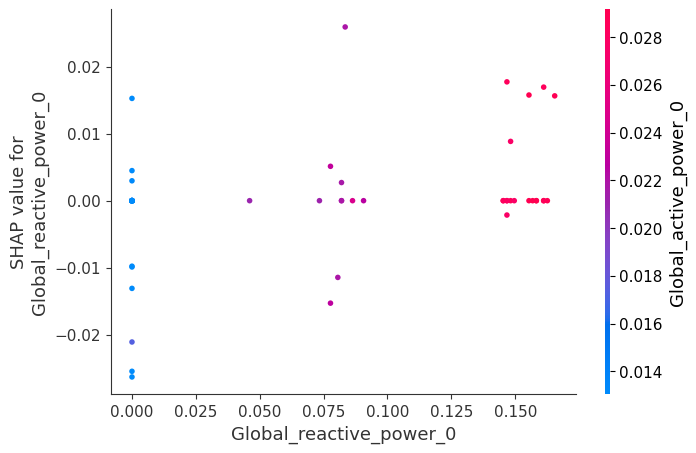

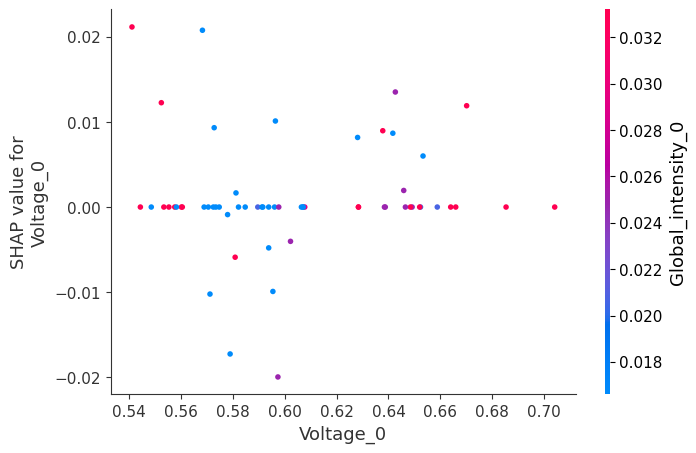

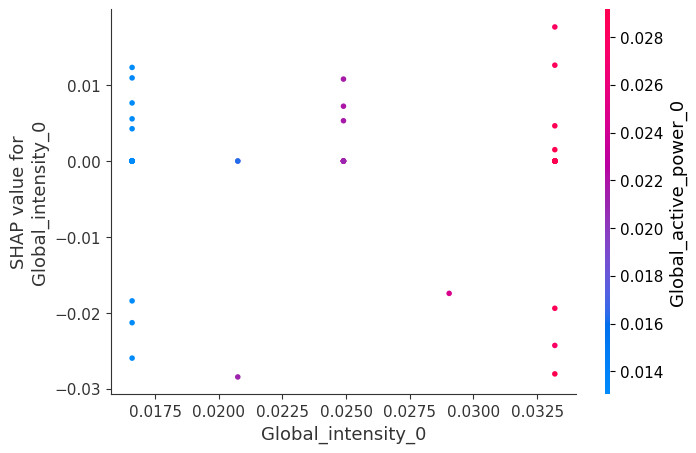

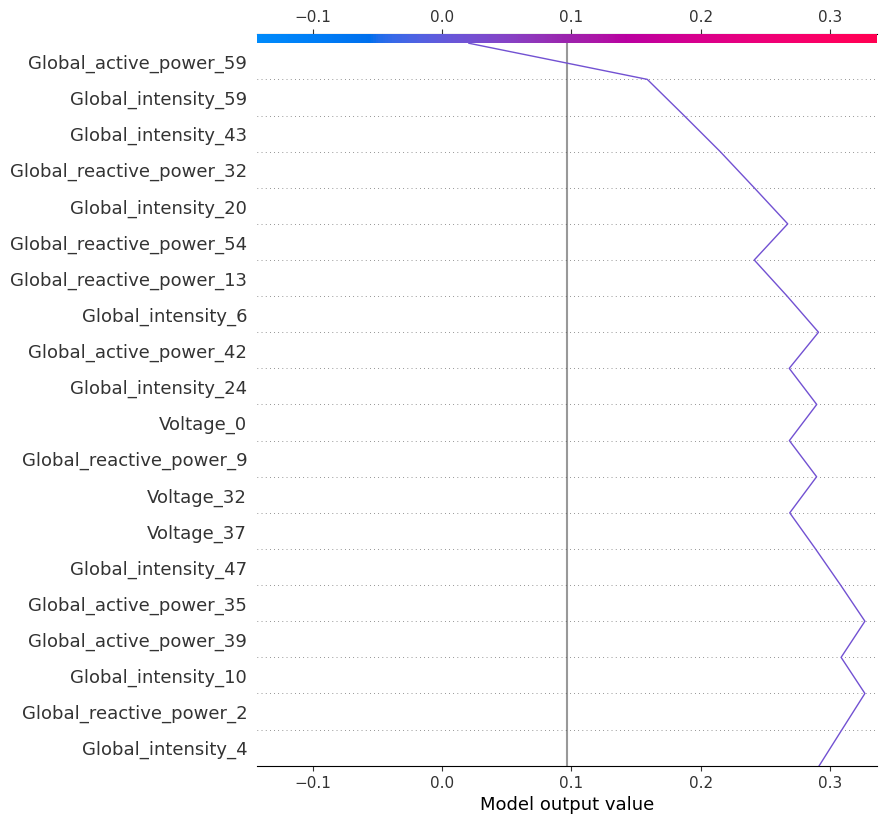

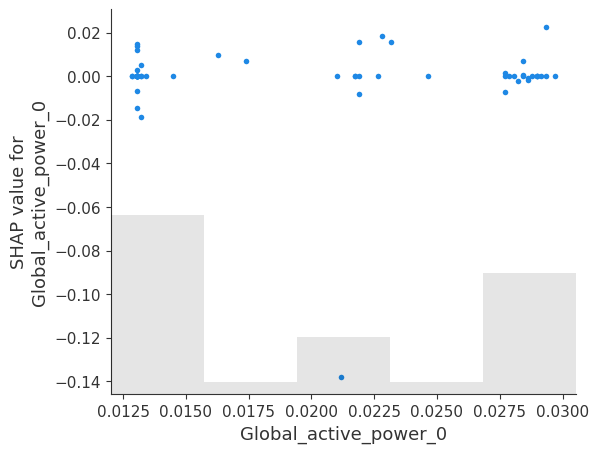

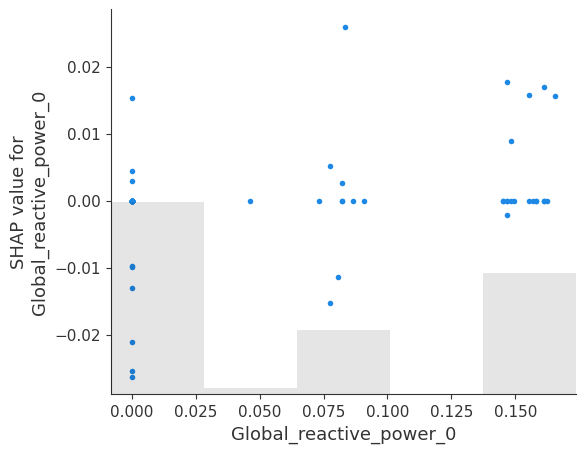

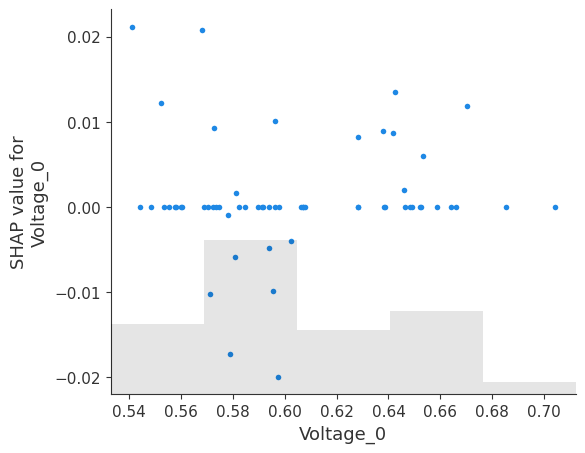

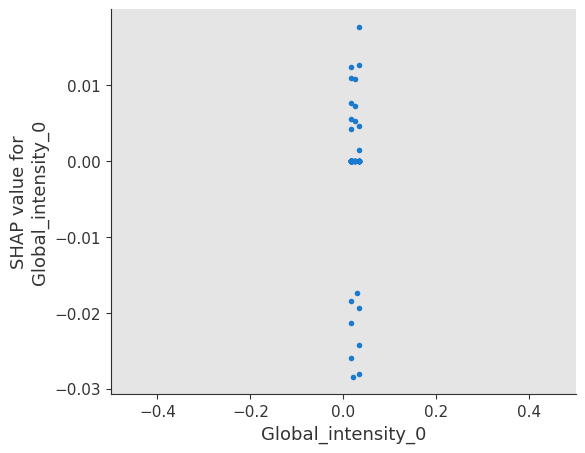

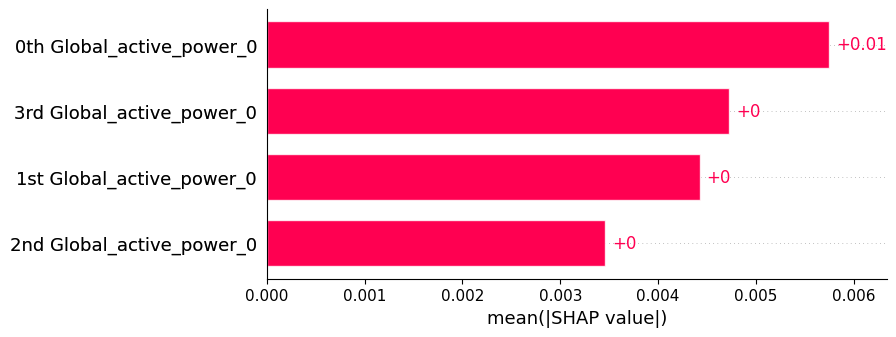

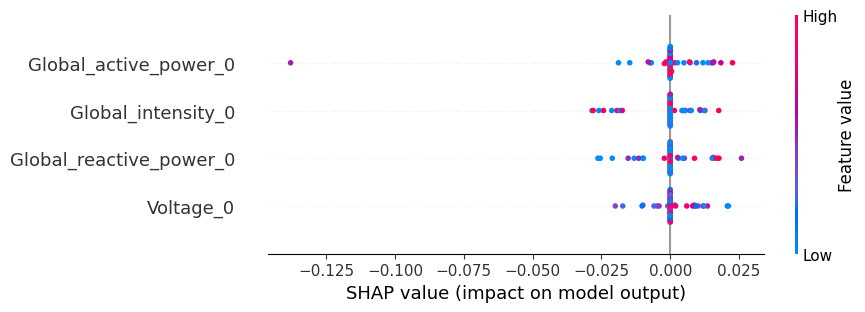

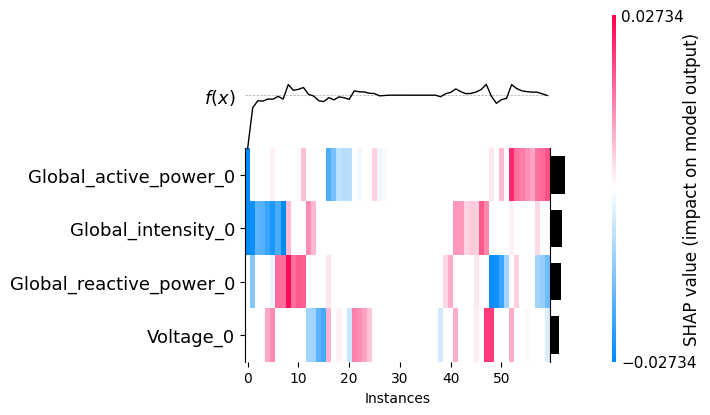

Feature Global_active_power not found in sample_df columns: Index(['Global_active_power_0', 'Global_reactive_power_0', 'Voltage_0',
       'Global_intensity_0'],
      dtype='object')


In [10]:
num_samples = 1  
shap_values, sampled_eval_sequences = explainer.explain(eval_sequences,
                                                             num_samples=num_samples)

explainer.visualize(shap_values, sampled_eval_sequences)

### Attention

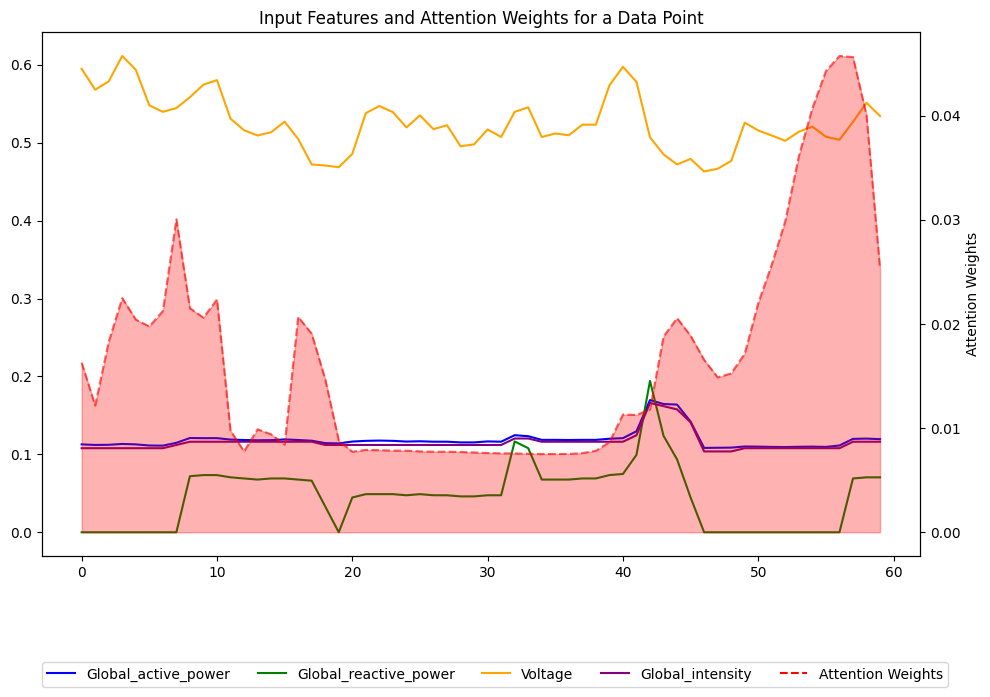

Prediction for the data point: 0.12013283371925354


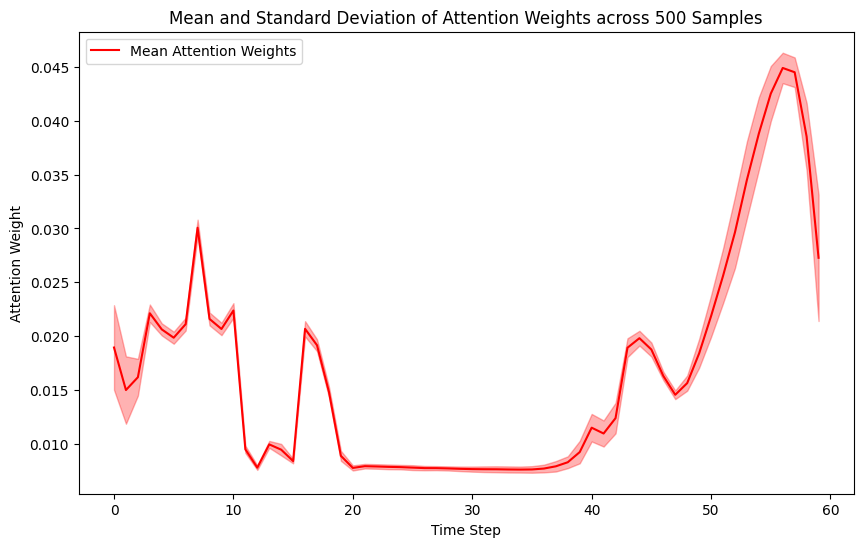

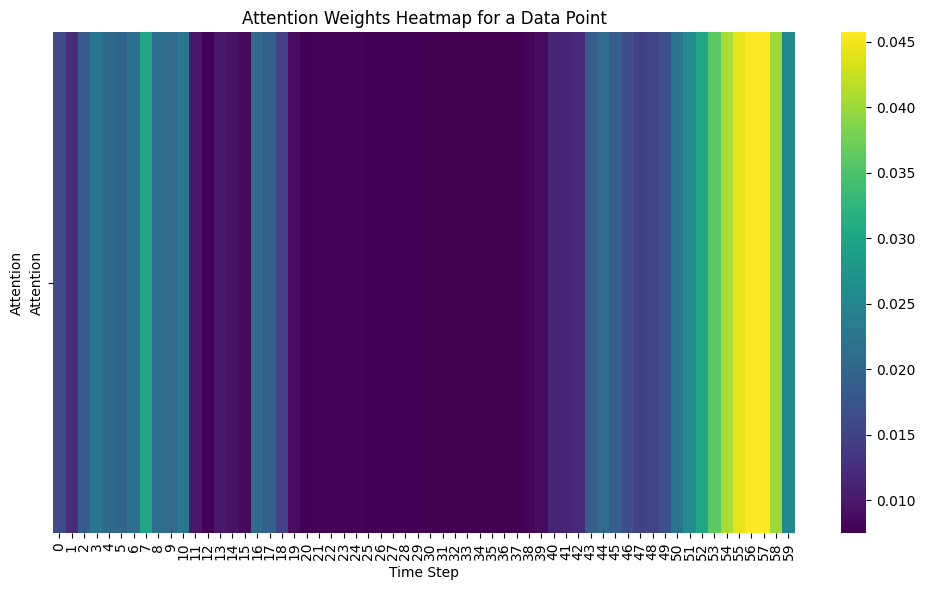

Prediction for the data point: 0.12013283371925354


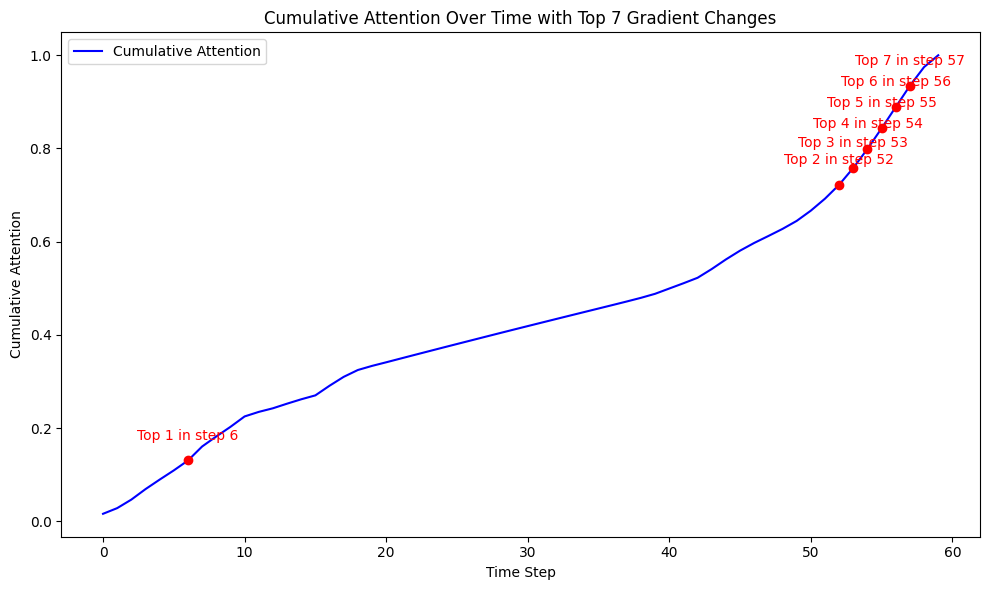

Prediction for the data point: 0.12013283371925354
Top 7 steps with largest gradient changes: [6, 52, 53, 54, 55, 56, 57]


In [7]:
# AttentionExplainer 클래스 생성
attention_explainer = AttentionExplainer(model, device, eval_sequences, 
                                         sequence_length=60, input_size=input_size, 
                                         selected_features=dataset.selected_features)

random_data_point = eval_sequences[np.random.choice(len(eval_sequences))]

attention_explainer.visualize_attention(random_data_point)

attention_explainer.analyze_attention_distribution(num_samples=500)

attention_explainer.visualize_attention_heatmap(random_data_point)

attention_explainer.visualize_cumulative_attention(random_data_point)


### Grad-CAM (현재 구현중)

- 입력에 대한 기여도 (하나의 time step에서 featureㅂ별 기여도는 동일)

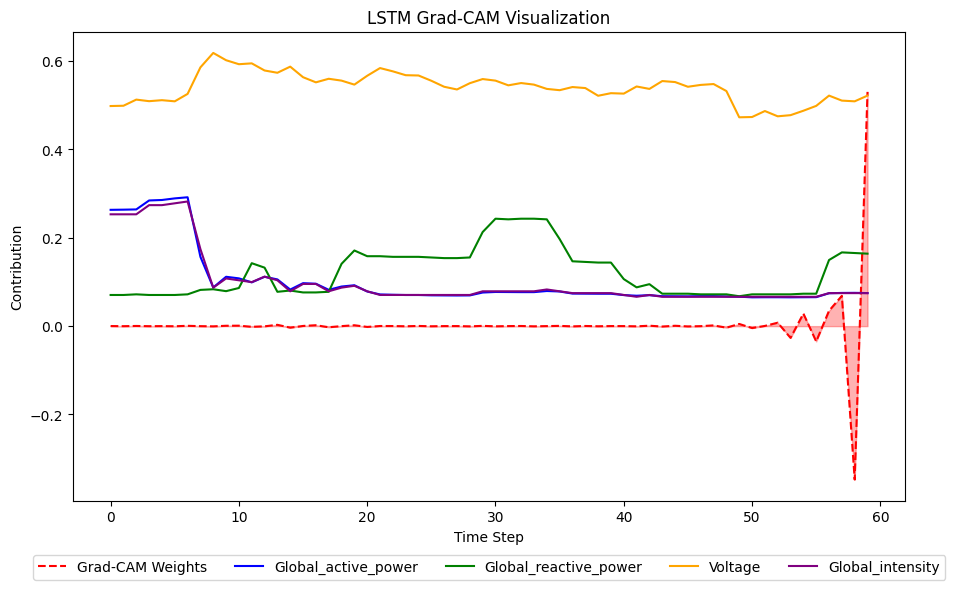

In [88]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def compute_grad_cam_lstm(model, data_point, target_index=None):
    """
    Grad-CAM을 LSTM 기반 모델에 적용하여 각 타임스텝의 기여도를 계산합니다.
    
    Args:
        model: LSTM 기반 예측 모델
        data_point: 시계열 데이터 포인트 (sequence_length, input_size)
        target_index: 목표 예측값의 인덱스 (분류 모델에서 사용 가능)
    
    Returns:
        Grad-CAM으로 계산된 각 타임스텝의 기여도 맵
    """
    model.train()  # 모델을 train 모드로 전환하여 backward 계산 가능하도록 설정
    
    # 텐서에 requires_grad=True 설정하여 gradient 계산 가능하도록 설정
    data_tensor = torch.tensor(data_point, dtype=torch.float32).unsqueeze(0).to(device)  # (1, sequence_length, input_size)
    
    # Hook 설정: 입력 텐서의 gradient를 추적
    data_tensor.requires_grad_(True)

    gradients = []
    
    def hook_fn(grad):
        gradients.append(grad)
    
    # Forward pass to get output
    output = model(data_tensor)
    
    if target_index is not None:
        output = output[:, target_index]
    
    # Zero the gradients
    model.zero_grad()
    
    # 입력 텐서에 대해 backward hook 설정
    handle = data_tensor.register_hook(hook_fn)
    
    # Backward pass to calculate gradients of the output w.r.t the input sequence
    output.backward(torch.ones_like(output))
    
    # Hook을 통해 gradient 추출
    handle.remove()
    
    gradients = gradients[0].cpu().detach().numpy().squeeze()  # (sequence_length, input_size)
    
    # Grad-CAM 가중치: 각 타임스텝에 대한 기여도 계산 (input_size의 평균을 취함)
    grad_cam_weights = np.mean(gradients, axis=1)  # (sequence_length,)
    
    model.eval()  # 모델을 다시 eval 모드로 전환
    
    return grad_cam_weights

def visualize_grad_cam_lstm(grad_cam_weights, data_point, selected_features):
    """
    Grad-CAM으로 계산된 타임스텝 기여도를 시각화합니다.
    
    Args:
        grad_cam_weights: Grad-CAM으로 계산된 가중치 (sequence_length,)
        data_point: 시계열 데이터 포인트 (sequence_length, input_size)
        selected_features: 사용된 feature의 이름 리스트
    """
    sequence_length = data_point.shape[0]  # 타임스텝 길이
    
    # Grad-CAM 가중치 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(grad_cam_weights, label='Grad-CAM Weights', color='red', linestyle='--')
    plt.fill_between(range(sequence_length), grad_cam_weights, color='red', alpha=0.3)
    
    # 데이터 포인트 시각화
    feature_colors = ['blue', 'green', 'orange', 'purple']  # Feature 색상 리스트
    for i in range(data_point.shape[1]):  # feature 개수만큼 반복
        plt.plot(data_point[:, i], label=selected_features[i], color=feature_colors[i % len(feature_colors)])
    
    # 그래프 설정
    plt.title("LSTM Grad-CAM Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Contribution")
    
    # 레전드를 그래프 밖에 위치시킴
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(selected_features) + 1)
    
    plt.tight_layout()
    plt.show()



# 사용 예시
data_point = eval_sequences[np.random.choice(len(eval_sequences))]
grad_cam_weights = compute_grad_cam_lstm(model, data_point)
visualize_grad_cam_lstm(grad_cam_weights, data_point, dataset.selected_features)


In [93]:
def compute_grad_cam_lstm_per_feature(model, data_point, target_index=None):
    """
    Grad-CAM을 LSTM 기반 모델에 적용하여 각 타임스텝과 각 feature별 기여도를 계산합니다.
    
    Args:
        model: LSTM 기반 예측 모델
        data_point: 시계열 데이터 포인트 (sequence_length, input_size)
        target_index: 목표 예측값의 인덱스 (분류 모델에서 사용 가능)
    
    Returns:
        Grad-CAM으로 계산된 각 타임스텝과 각 feature의 기여도 맵 (sequence_length, input_size)
    """
    model.train()  # 모델을 train 모드로 전환하여 backward 계산 가능하도록 설정
    
    # 텐서에 requires_grad=True 설정하여 gradient 계산 가능하도록 설정
    data_tensor = torch.tensor(data_point, dtype=torch.float32).unsqueeze(0).to(device)  # (1, sequence_length, input_size)
    
    # Hook 설정: 입력 텐서의 gradient를 추적
    data_tensor.requires_grad_(True)

    gradients = []
    
    def hook_fn(grad):
        gradients.append(grad)
    
    # Forward pass to get output
    output = model(data_tensor)
    
    if target_index is not None:
        output = output[:, target_index]
    
    # Zero the gradients
    model.zero_grad()
    
    # 입력 텐서에 대해 backward hook 설정
    handle = data_tensor.register_hook(hook_fn)
    
    # Backward pass to calculate gradients of the output w.r.t the input sequence
    output.backward(torch.ones_like(output))
    
    # Hook을 통해 gradient 추출
    handle.remove()
    
    gradients = gradients[0].cpu().detach().numpy().squeeze()  # (sequence_length, input_size)
    
    model.eval()  # 모델을 다시 eval 모드로 전환
    
    # Grad-CAM 가중치: 각 타임스텝과 feature별 기여도
    return gradients  # (sequence_length, input_size)

def visualize_grad_cam_per_feature(grad_cam_weights, data_point, selected_features):
    """
    Grad-CAM으로 계산된 타임스텝과 feature별 기여도를 시각화합니다.
    
    Args:
        grad_cam_weights: Grad-CAM으로 계산된 가중치 (sequence_length, input_size)
        data_point: 시계열 데이터 포인트 (sequence_length, input_size)
        selected_features: 사용된 feature의 이름 리스트
    """
    sequence_length, input_size = grad_cam_weights.shape
    
    feature_colors = ['blue', 'green', 'orange', 'purple']  # Feature 색상 리스트
    
    # 전체 feature의 기여도를 하나의 그래프에 시각화
    plt.figure(figsize=(12, 6))
    for i in range(input_size):
        plt.plot(grad_cam_weights[:, i], label=f'{selected_features[i]} Grad-CAM', color=feature_colors[i % len(feature_colors)])
        plt.fill_between(range(sequence_length), grad_cam_weights[:, i], color=feature_colors[i % len(feature_colors)], alpha=0.3)
    
    # 그래프 설정
    plt.title("Combined Grad-CAM Feature Contribution")
    plt.xlabel("Time Step")
    plt.ylabel("Feature Contribution")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(selected_features))
    plt.tight_layout()
    plt.show()

    # 각 feature별로 개별 그래프 생성
    for i in range(input_size):
        plt.figure(figsize=(10, 6))
        
        # 해당 feature의 Grad-CAM 가중치 시각화
        plt.plot(grad_cam_weights[:, i], label=f'{selected_features[i]} Grad-CAM', color=feature_colors[i % len(feature_colors)])
        plt.fill_between(range(sequence_length), grad_cam_weights[:, i], color=feature_colors[i % len(feature_colors)], alpha=0.3)
        
        # 그래프 설정
        plt.title(f"{selected_features[i]} Grad-CAM Feature Contribution")
        plt.xlabel("Time Step")
        plt.ylabel("Feature Contribution")
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

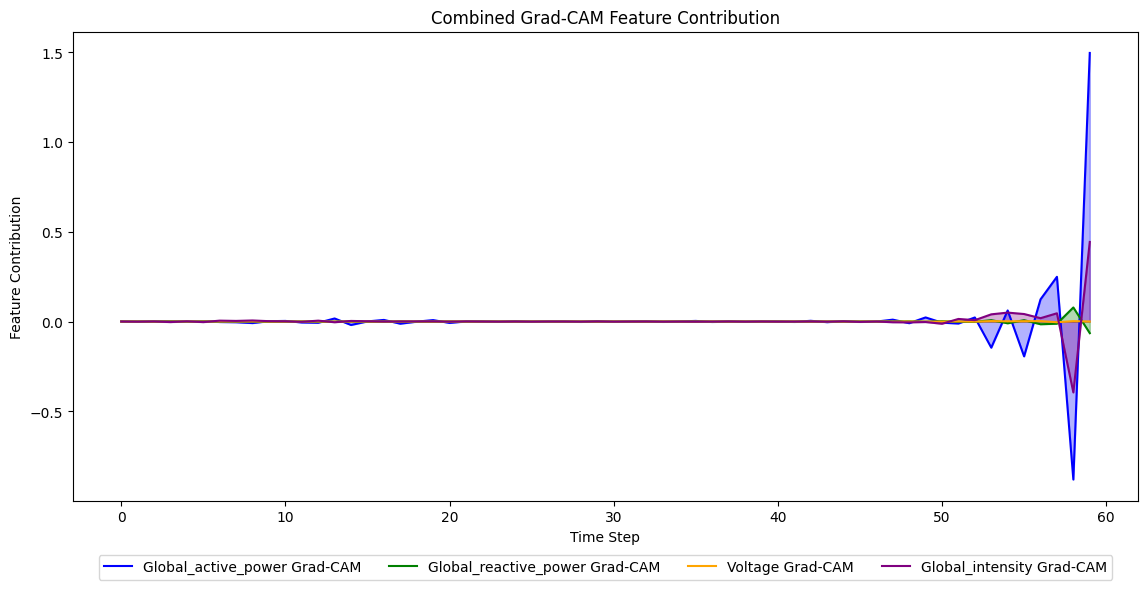

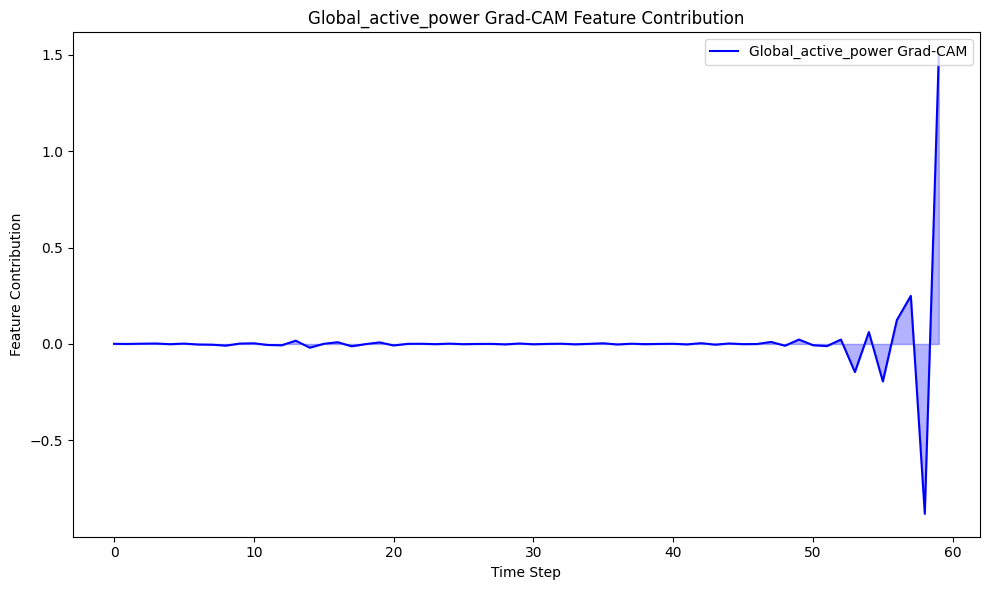

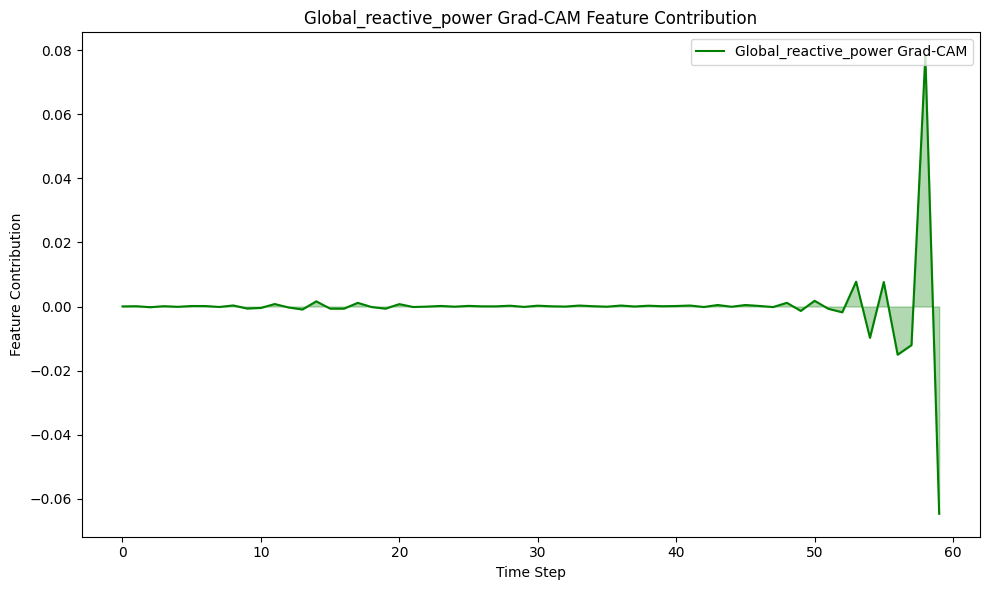

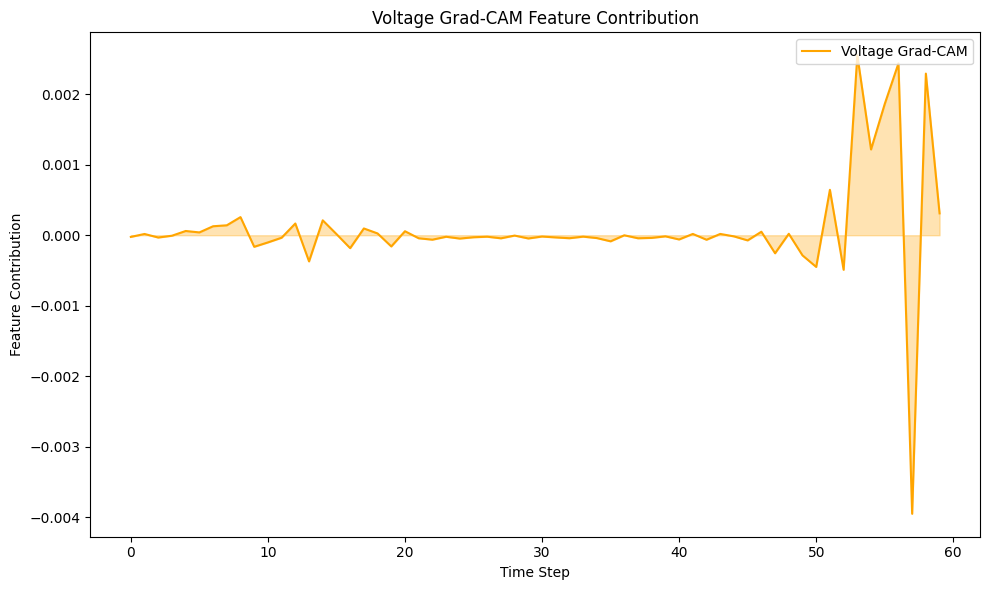

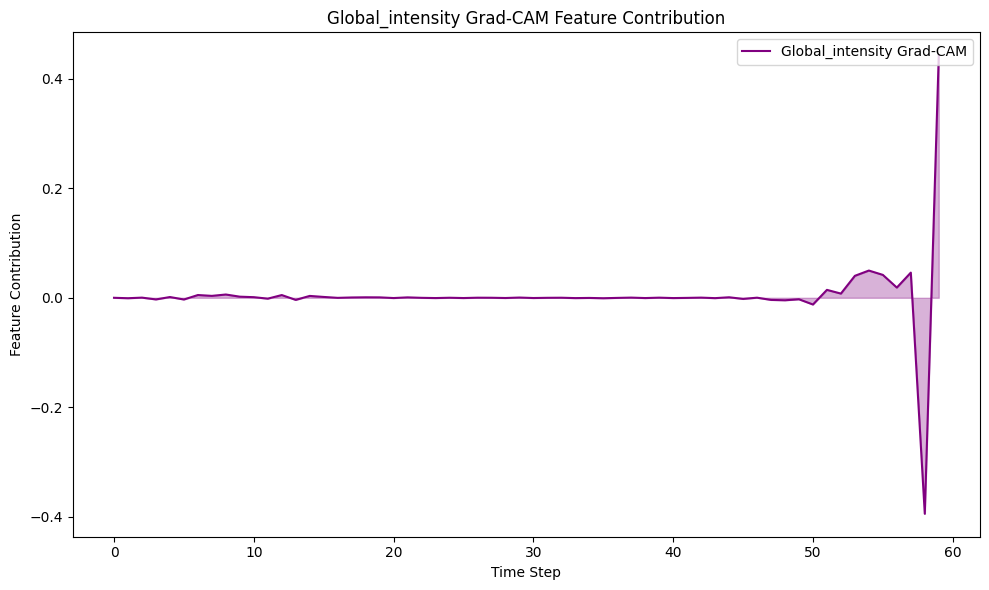

In [94]:
# 모델에 Feature별 Grad-CAM 적용
grad_cam_weights_per_feature = compute_grad_cam_lstm_per_feature(model, data_point)

# Grad-CAM 가중치 시각화 (Feature별로)
visualize_grad_cam_per_feature(grad_cam_weights_per_feature, data_point, dataset.selected_features)

## 앞으로 할일
- Feature 간 상관관계 분석 (SHAP?)
    - 특정 종속 feature가 있는지
    - 중요 feature / 종속 feature 찾아지면, feature 중요도에 따라 성능 변화 실험
- 각 설명모듈의 시각화 결과에 대한 전문화된 설명 생성(템플릿 기반)
- 다른 Explainer 추가 (LRP, Gradient 기반 등)
- (optional) 데이터 분포 시각화